In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 리눅스 나눔 폰트 직접 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False



# tensorflow import mnist

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

I0000 00:00:1774831597.535354    2691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774831597.869791    2691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774831602.284177    2691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


((60000, 28, 28), (10000, 28, 28))

In [3]:
type(X_train)

numpy.ndarray

In [4]:
#픽셀값 정규화
X_train = X_train.reshape(-1, 28, 28, 1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# 합성곱 신경망의 구조  

In [5]:
from tensorflow.keras import Sequential, layers
model = Sequential(
  [
    layers.Input(shape=(28,28,1)), #3차원 이미지 1장의 입력
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), #분류 계층
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
  ])
model.summary()

I0000 00:00:1774831609.202367    2691 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 모델

In [6]:
model.layers[0].get_weights() #초기값 (랜덤)

[array([[[[-3.29687893e-02,  1.06537372e-01, -7.24673048e-02,
           -3.54418159e-03, -4.12141904e-02,  1.10176846e-01,
           -5.37925661e-02,  9.40162987e-02, -3.76319289e-02,
            4.93228883e-02,  1.11826405e-01,  6.67850077e-02,
           -2.87296921e-02, -4.81419191e-02, -2.86393464e-02,
            7.18610287e-02,  2.88050473e-02, -7.98636898e-02,
           -6.44567087e-02, -6.60303012e-02,  3.12701166e-02,
           -1.10690325e-01,  1.23344675e-01, -8.57775733e-02,
            1.76617801e-02,  4.28992361e-02,  8.07178617e-02,
            1.24180153e-01,  4.36124355e-02,  7.08867013e-02,
            1.50393397e-02, -1.00870594e-01]],
 
         [[-9.90162045e-02, -5.07407710e-02, -2.73676515e-02,
            3.66732925e-02,  7.39077479e-02,  8.79840404e-02,
           -6.72188327e-02, -1.05534606e-01, -1.10134408e-01,
           -6.22012317e-02, -1.06966823e-01, -9.72296670e-02,
           -7.07259327e-02,  8.36335272e-02,  1.31571129e-01,
            1.1548571

# 컴파일

In [7]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10,
                        validation_split=0.2, #추가 
                      verbose=1)

Epoch 1/10


I0000 00:00:1774831610.956505    3250 service.cc:153] XLA service 0x74ff180331f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774831610.956531    3250 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774831610.981750    3250 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774831611.111680    3250 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774831611.164130    3250 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1791__.33


 61/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4396 - loss: 1.6575

I0000 00:00:1774831615.391226    3250 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8755 - loss: 0.3951 - val_accuracy: 0.9748 - val_loss: 0.0883
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9592 - loss: 0.1362 - val_accuracy: 0.9830 - val_loss: 0.0597
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9698 - loss: 0.1008 - val_accuracy: 0.9838 - val_loss: 0.0553
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0830 - val_accuracy: 0.9857 - val_loss: 0.0476
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9786 - loss: 0.0713 - val_accuracy: 0.9874 - val_loss: 0.0420
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9811 - loss: 0.0627 - val_accuracy: 0.9882 - val_loss: 0.0431
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0565 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9834 - loss: 0.0529 - val_accuracy: 0.9900 - val

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9915 - loss: 0.0238


# 시각화

In [10]:
import matplotlib.pyplot as plt
import numpy as np


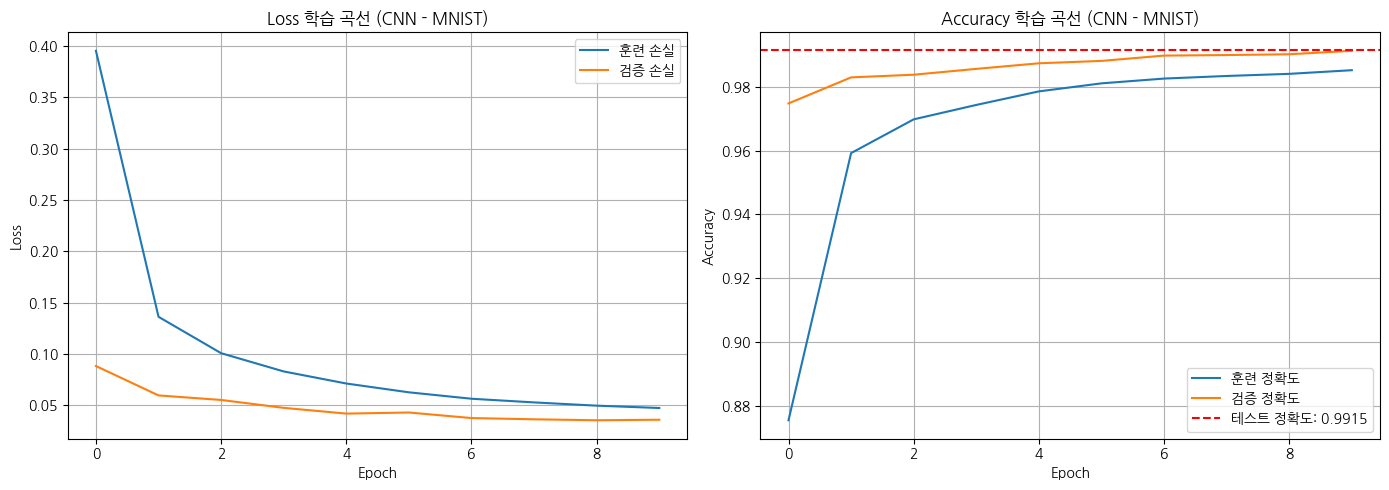

테스트 Loss    : 0.0238
테스트 Accuracy: 99.15%


In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선 (CNN - MNIST)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선 (CNN - MNIST)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# 테스트 정확도 기준선 추가
axes[1].axhline(y=acc, color='red', linestyle='--',
                label=f'테스트 정확도: {acc:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc*100:.2f}%")

# END

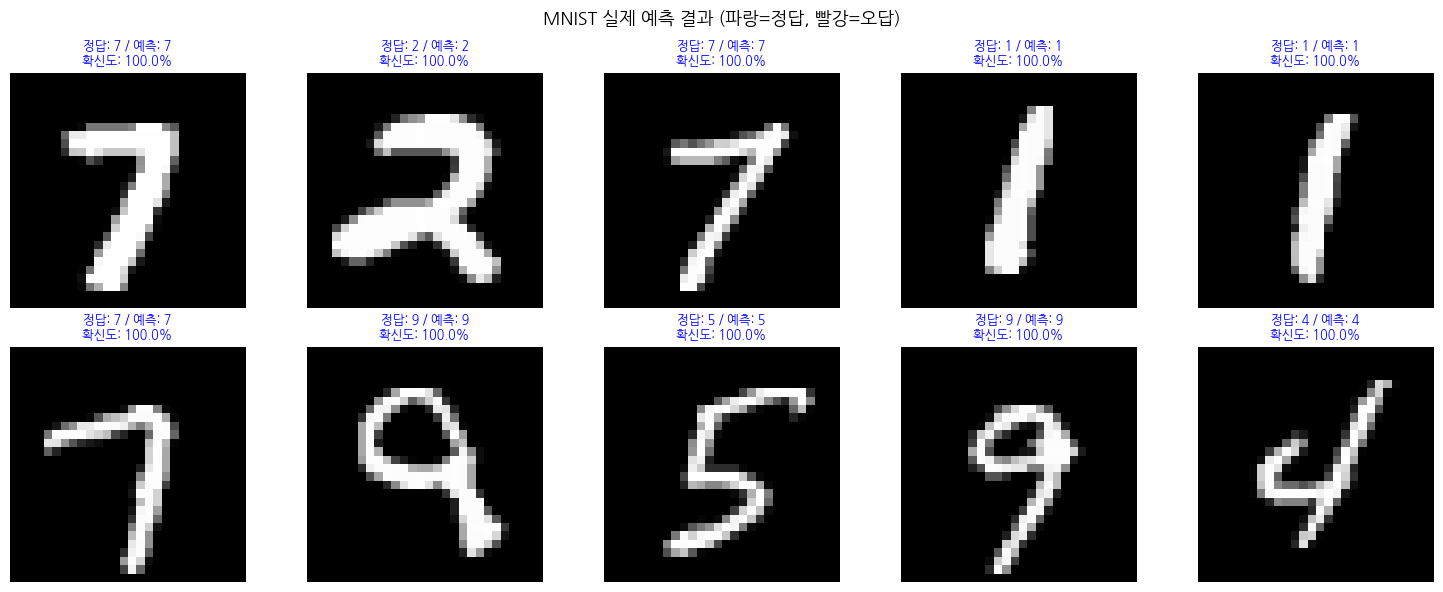

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 테스트 이미지 10개 랜덤 선택
indices = np.random.randint(0, len(X_test), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]

    # 예측
    pred_prob  = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(pred_prob)
    confidence = pred_prob[0][pred_label] * 100

    # 시각화
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f'정답: {true_label} / 예측: {pred_label}\n확신도: {confidence:.1f}%',
        color='blue' if true_label == pred_label else 'red',
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('MNIST 실제 예측 결과 (파랑=정답, 빨강=오답)', fontsize=13)
plt.tight_layout()
plt.show()

# RESNET 전이학습

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [14]:
resnet_model = ResNet50(input_shape=(224, 224, 3), include_top=False)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

# 이미지 로드

In [34]:
from tensorflow.keras.applications import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import decode_predictions
import numpy as np

ImportError: cannot import name 'preprocess_input' from 'tensorflow.keras.applications' (/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/_tf_keras/keras/applications/__init__.py)

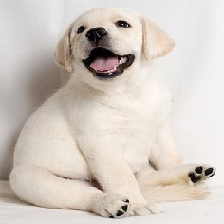

(1, 224, 224, 3)

In [31]:
# 1. 이미지 로드
rab_img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
display(rab_img) 

# 2. 배열 변환 + 차원 추가
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X.shape

In [25]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np

# 모델 로드
model = ResNet50(weights='imagenet')

# 이미지 로드 및 전처리
img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
X = image.img_to_array(img)          # shape: (224, 224, 3)
X = np.expand_dims(X, axis=0)        # shape: (1, 224, 224, 3)
X = preprocess_input(X)              # ResNet50 전용 정규화

# 예측
pred = model.predict(X, verbose=0)
print('Predicted:', decode_predictions(pred, top=3))

Predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.79137677)), ('n02099601', 'golden_retriever', np.float32(0.13176224)), ('n02104029', 'kuvasz', np.float32(0.04098354))]]


In [26]:
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X.shape

(1, 224, 224, 3)

# 추론 ResNet Model

In [27]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np

# 모델 로드
resnet_model = ResNet50(weights='imagenet')

# 이미지 로드 및 전처리
rab_img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X = preprocess_input(X)

# 추론
pred = resnet_model.predict(X)
print('Predicted:', decode_predictions(pred, top=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.79137677)), ('n02099601', 'golden_retriever', np.float32(0.13176224)), ('n02104029', 'kuvasz', np.float32(0.04098354))]]


In [30]:
# decode_predictions는 이미 상단에서 import 완료된 상태
result = decode_predictions(pred, top=3)

for _, label, score in result[0]:
    print(f'{label}: {score:.4f}')


# 출력 예시:
#Labrador_retriever: 0.9123
# golden_retriever: 0.0421
# kuvasz: 0.0187

Labrador_retriever: 0.7914
golden_retriever: 0.1318
kuvasz: 0.0410


#  전이 학습

In [36]:
resnet_model_tl = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
resnet_model_tl.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

# 전이학습모델

In [ ]:
resnet_model_tl.trainable = True

# 전이학습모델
model = Sequential()
model.add(resnet_model_tl)
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,352,259 (482.00 MB)

 Trainable params: 126,299,139 (481.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

# zipfile

In [44]:
import zipfile
zip_file_path = 'glaucoma.zip' #압축파일

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('./datasets/')

# Train_gen_data

In [45]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_gen = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.2,
  height_shift_range=0.2,
  horizontal_flip=True,
)
train_gen_data = train_gen.flow_from_directory(
    './datasets/glaucoma/train', target_size=(224, 224), batch_size=32, class_mode='sparse'
)

Found 1394 images belonging to 3 classes.


# Test Data

In [46]:
test_gen = ImageDataGenerator()
test_data = test_gen.flow_from_directory(
    './datasets/glaucoma/test', target_size=(224, 224), batch_size=32, class_mode='sparse'
)

Found 150 images belonging to 3 classes.


In [48]:
train_gen_data.image_shape, test_data.image_shape 

((224, 224, 3), (224, 224, 3))

# 모델 설정


In [54]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [55]:
# 모델 전이학습
model.fit(
  train_gen_data, validation_data=test_data, epochs=20, verbose=1  
)

Epoch 1/20


I0000 00:00:1774840765.838004    3248 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108487__.391


 2/44 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.3750 - loss: 33.8194

I0000 00:00:1774840793.071487    3247 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108487__.391


44/44 ━━━━━━━━━━━━━━━━━━━━ 87s 920ms/step - accuracy: 0.6456 - loss: 8.3040 - val_accuracy: 0.5200 - val_loss: 202041296.0000
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.6786 - loss: 1.2275 - val_accuracy: 0.5200 - val_loss: 838.4742
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.7066 - loss: 0.7280 - val_accuracy: 0.4733 - val_loss: 30.7925
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 266ms/step - accuracy: 0.6958 - loss: 0.6493 - val_accuracy: 0.6533 - val_loss: 1.0728
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.7209 - loss: 0.6312 - val_accuracy: 0.6600 - val_loss: 0.7706
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.7346 - loss: 0.5926 - val_accuracy: 0.7133 - val_loss: 0.7034
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.7396 - loss: 0.5841 - val_accuracy: 0.6667 - val_loss: 1.0336
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - accuracy: 0.7403 - loss: 0.5901 - val_accuracy:

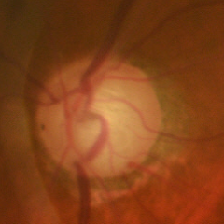

In [50]:
from tensorflow.keras.preprocessing import image
grau_img = image.load_img('test.png', target_size=(224, 224))
grau_img

In [51]:
X = np.expand_dims(image.img_to_array(grau_img), axis=0) 


In [56]:
pred = model.predict(X, verbose=0)
pred


array([[0.450965  , 0.3029896 , 0.24604544]], dtype=float32)